In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [20]:
class KNN_MANUAL:
    def __init__(self, k):
        self.k = k
    
    def fit(self, X_train, y_train):
        self.x_train = np.array(X_train)
        self.y_train = np.array(y_train)
    
    def predict(self, inputs):
        y_pred = []
        for i in inputs:
            distances = np.linalg.norm(self.x_train - i, axis=1)

            indices = np.argsort(distances)[:self.k]

            label_counts = {}
            for idx in indices:
                label = self.y_train[idx]
                label_counts[label] = label_counts.get(label, 0) + 1

            most_common_label = max(sorted(label_counts), key=label_counts.get)
            y_pred.append(most_common_label)

        return np.array(y_pred)


In [3]:
df = pd.read_csv('telescope_data.csv')

## DATA PREPROCESSING

In [4]:
df.head()


,Unnamed: 0,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [5]:
df = df.drop(df.columns[0],axis = 1)

In [6]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [7]:
df = df.drop(df[df['class'] == 'g'].sample(n=5644,random_state=42).index)


In [8]:
df['class'].value_counts()

class
g    6688
h    6688
Name: count, dtype: int64

## Encoding Categorical Data

In [12]:
df['class'] = df['class'].map({'g':0,'h':1})

In [13]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.261,0
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.788,0
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.462,0
5,51.6240,21.1502,2.9085,0.2420,0.1340,50.8761,43.1887,9.8145,3.6130,238.098,0
6,48.2468,17.3565,3.0332,0.2529,0.1515,8.5730,38.0957,10.5868,4.7920,219.087,0


In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('class', axis=1)
y = df['class']


x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
x_test,x_val,y_test,y_val = train_test_split(x_test, y_test, test_size=0.5, random_state=42)

## Scalling the data

In [10]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

## Getting the best K Using Built-in KNN

```
Trying K from 1 to 15 to get the best k (with the highest accuracy on the validation data set)
```

In [11]:


accuracy_val_builtIn = []
input_range = range(1, 150)

for i in input_range :
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_val)
    accuracy_val_builtIn.append(accuracy_score(y_val, y_pred))


print (" Max accuracy is : "+str(max(accuracy_val_builtIn)) + ",At k =  " + str(accuracy_val_builtIn.index(max(accuracy_val_builtIn))))  # to get the max accuracy while using the k in training


 Max accuracy is : 0.809666168410563,At k =  34


In [12]:
accuracy_train_builtIn = []

for i in input_range :
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    
    y_pred = knn.predict(x_train)
    accuracy_train_builtIn.append(accuracy_score(y_train, y_pred))

### PLOTTING ACCURACIES 

In [13]:
def plot_accuracies(ranges, accuracies,num_of_accuracies=1):
    plt.figure(figsize=(30,6))
    for i in range(num_of_accuracies):
        plt.plot(ranges, accuracies[i], marker='o')
        plt.xlabel('Number of Neighbors K')
        plt.ylabel('Accuracy')
    plt.show()

``` validation accuracies```

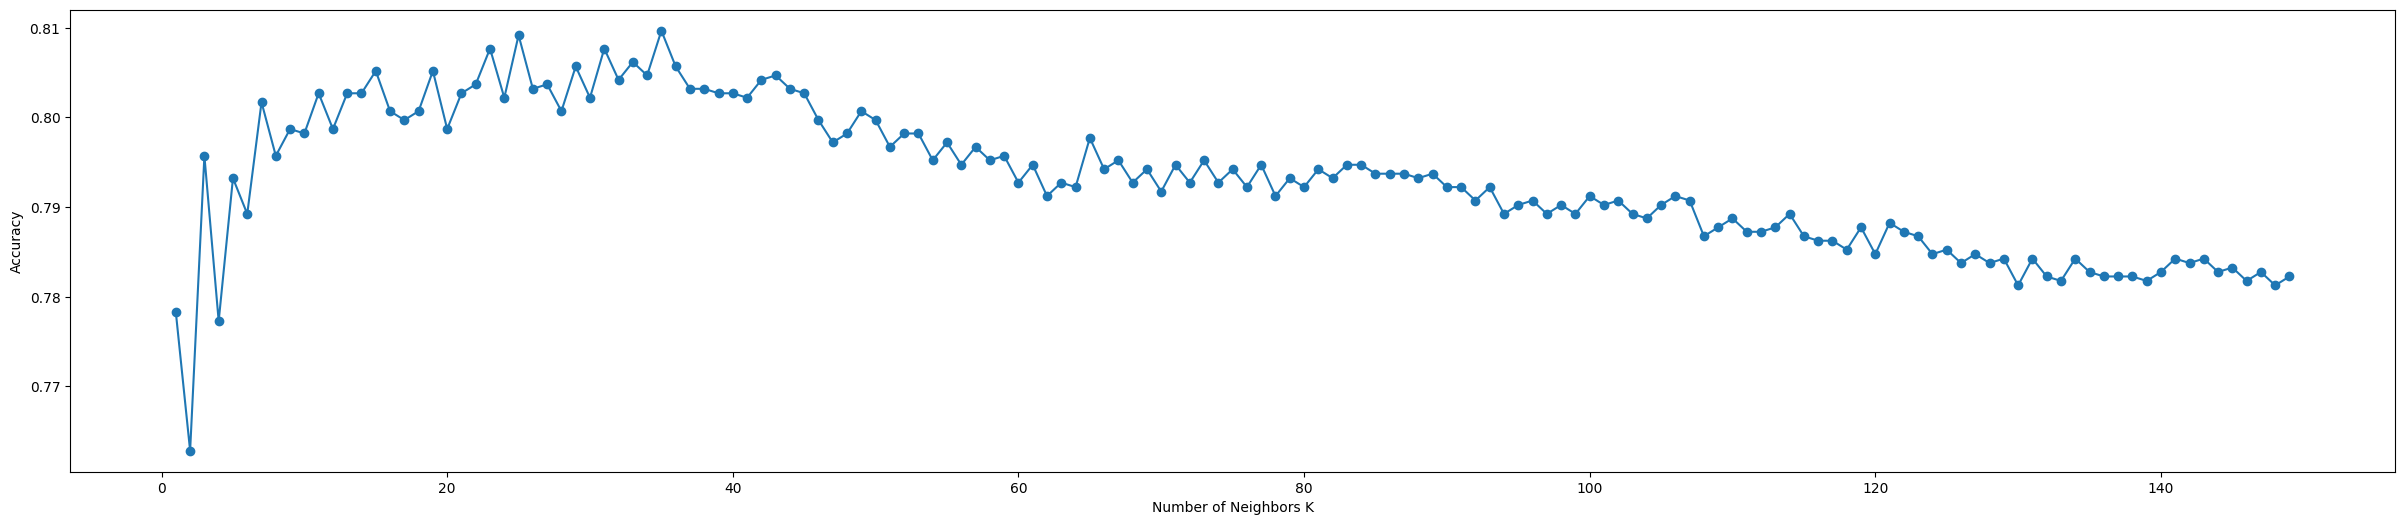

In [14]:
accuracies = [accuracy_val_builtIn]
plot_accuracies(input_range, accuracies)

``` training accuracies```

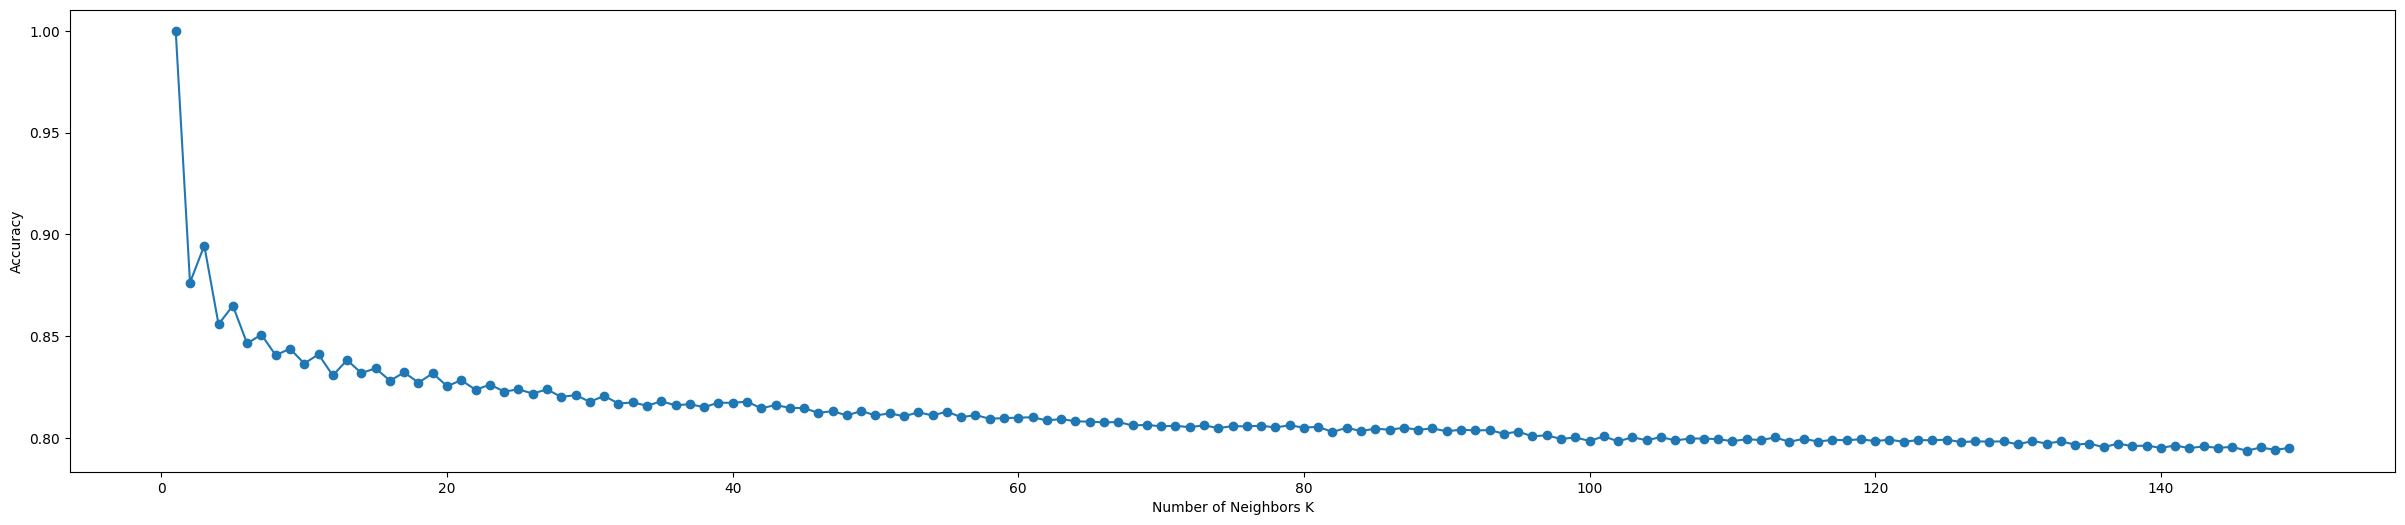

In [15]:
accuracies = [accuracy_train_builtIn]
plot_accuracies(input_range, accuracies)

```Plotting the accuracies in the same graph to get better visualization```

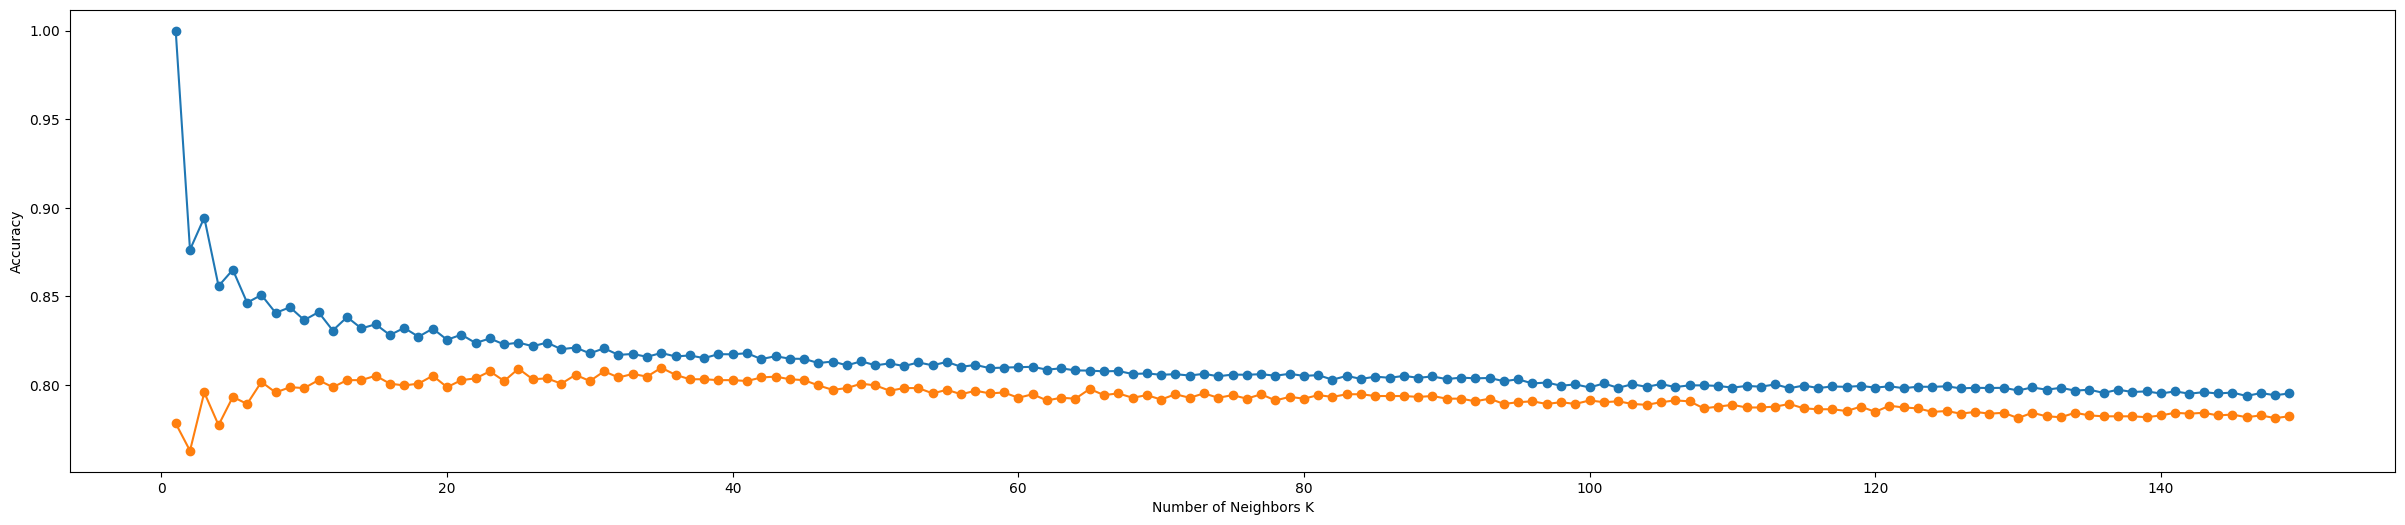

In [16]:
accuracies = [accuracy_train_builtIn, accuracy_val_builtIn]

plot_accuracies(input_range, accuracies, num_of_accuracies=2)

In [19]:
knn = KNeighborsClassifier(n_neighbors=34)
knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)

accuracy_test_builtIn = accuracy_score(y_test, y_pred)
print("Test Accuracy is : "+str(accuracy_test_builtIn))
    

Test Accuracy is : 0.8030907278165503


## Getting the best K Using Custom KNN

``` Trying K from 1 to 15 to get the best k (with the highest accuracy on the validation data set) ```

In [18]:
acccuracy_val_manual = []

input_range_manual = range(1, 150)

for i in input_range_manual :
    knn_manual = KNN_MANUAL(k=i)
    knn_manual.fit(x_train, y_train)
    
    y_pred = knn_manual.predict(x_val)

    
    acccuracy_val_manual.append(accuracy_score(y_val, y_pred))
    
print (" Max accuracy is : "+str(max(acccuracy_val_manual)) + ",At k =  " + str(acccuracy_val_manual.index(max(acccuracy_val_manual))))  # to get the max accuracy while using the k in training

NameError: name 'KNN_MANUAL' is not defined

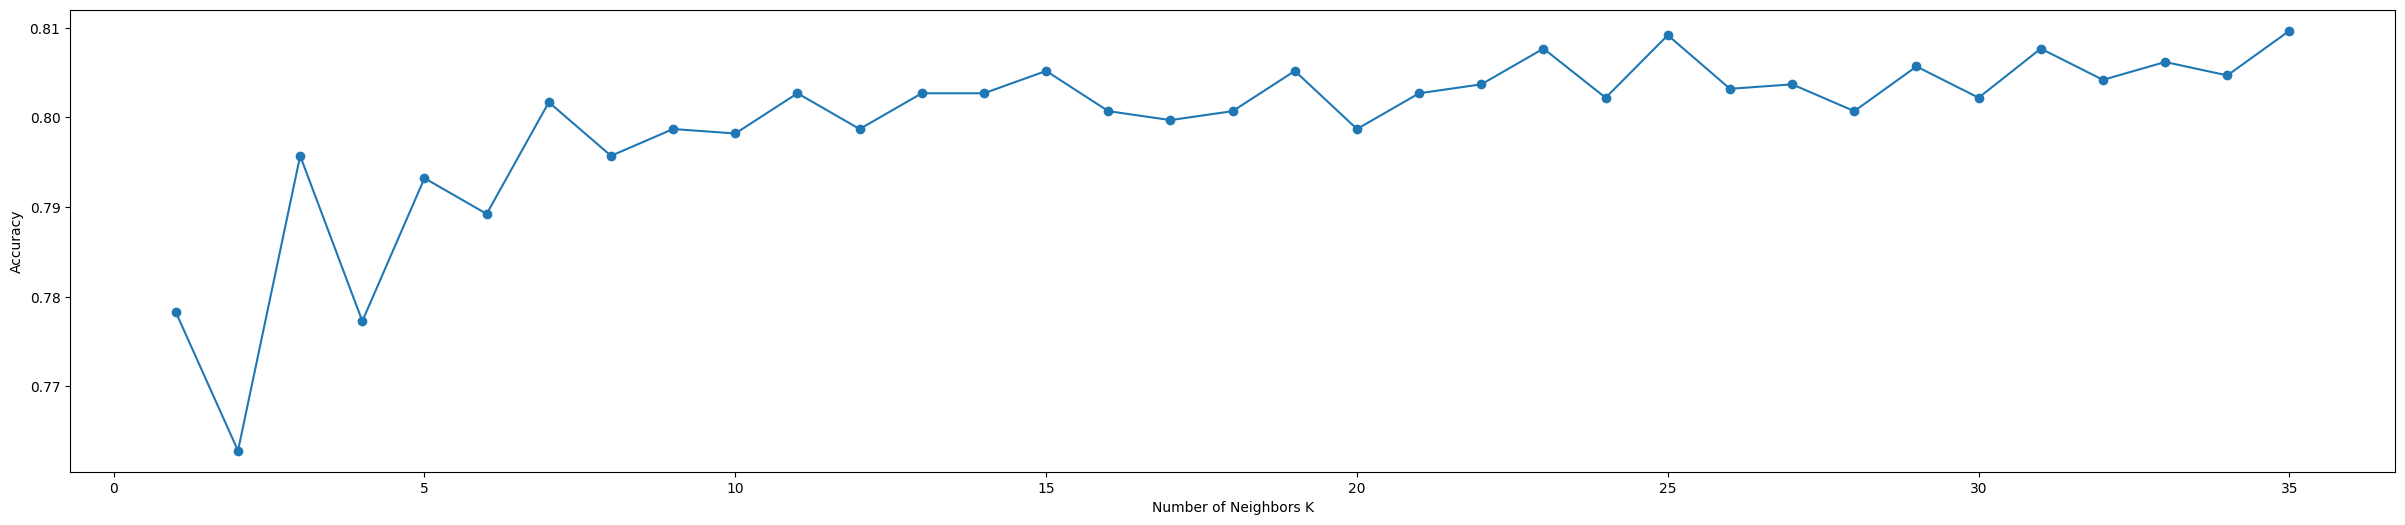

In [47]:
accuracies = [acccuracy_val_manual]
plot_accuracies(input_range_manual, accuracies)

## Test ACCuracies with the best K

``` Using the best k obtained from the validation set to get the test accuracy ```


In [46]:
knn = KNeighborsClassifier(n_neighbors=34)
knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)

accuracy_test_builtIn = accuracy_score(y_test, y_pred)
reacall = recall_score(y_test, y_pred)
presicion = precision_score(y_test, y_pred)
f_score = f1_score(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)



print("Test Accuracy is : "+str(accuracy_test_builtIn))
print("Test Recall is : "+str(reacall))
print("Test Precision is : "+str(presicion))
print("Test F1-Score is : "+str(f_score))
print("Confusion Matrix : \n"+str(matrix))


Test Accuracy is : 0.8030907278165503
Test Recall is : 0.7046370967741935
Test Precision is : 0.8726591760299626
Test F1-Score is : 0.7796988287785834
Confusion Matrix : 
[[912 102]
 [293 699]]


In [45]:
knn_manual = KNN_MANUAL(k=34)

knn_manual.fit(x_train, y_train)

y_pred = knn_manual.predict(x_test)

accuracy_test_manual = accuracy_score(y_test, y_pred)
recall_test_manual = recall_score(y_test, y_pred)
precision_test_manual = precision_score(y_test, y_pred)
f_score = f1_score(y_test, y_pred)
mat = confusion_matrix(y_test, y_pred)


print("Test Accuracy is : "+str(accuracy_test_manual))
print("Test Recall is : "+str(recall_test_manual))
print("Test Precision is : "+str(precision_test_manual))
print("Test F1-Score is : "+str(f_score))
print("Confusion Matrix : \n"+str(mat))

Test Accuracy is : 0.8030907278165503
Test Recall is : 0.7046370967741935
Test Precision is : 0.8726591760299626
Test F1-Score is : 0.7796988287785834
Confusion Matrix : 
[[912 102]
 [293 699]]
